## __Aprendizaje no supervisado__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: PCA - Features latentes

***

## Librerias

In [3]:
from time import time
from numpy.random import seed, shuffle
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA

## Dataset

La data es una colección de imágenes de personas famosas reolectada del internet que ha sido como un Benchmark para problemas de reconocimiento y verificacion de rostros. Este dataset contiene 5749 personas con alrededor de 13 mil imagenes disponible. Mayor información en [Labeled Faces in the Wild](http://vis-www.cs.umass.edu/lfw/).

<center>
    <img src='https://microsoft.github.io/DigiFace1M/img/sx-data.jpg' width=1200>
</center>

In [4]:
## Carga de datos
dataset = fetch_lfw_people(min_faces_per_person=60)

## Mostrar llaves de accedo
dataset.keys()

dict_keys(['data', 'images', 'target', 'target_names', 'DESCR'])

In [5]:
## Mostrar descripción m'as detalladas de los datos
print(dataset['DESCR'])

.. _labeled_faces_in_the_wild_dataset:

The Labeled Faces in the Wild face recognition dataset
------------------------------------------------------

This dataset is a collection of JPEG pictures of famous people collected
over the internet, and the details are available on the Kaggle website:

https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

Each picture is centered on a single face. The typical task is called
Face Verification: given a pair of two pictures, a binary classifier
must predict whether the two images are from the same person.

An alternative task, Face Recognition or Face Identification is:
given the picture of the face of an unknown person, identify the name
of the person by referring to a gallery of previously seen pictures of
identified persons.

Both Face Verification and Face Recognition are tasks that are typically
performed on the output of a model trained to perform Face Detection. The
most popular model for Face Detection is called Viola-Jones and is
i

In [6]:
## Mostrar etiquetas asignadas por expertos
dataset['target_names']

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Junichiro Koizumi',
       'Tony Blair'], dtype='<U17')

In [7]:
## Mostrar la cantidad y la dimension de las imagenes seleccionadas
print(dataset['images'].shape)

(1348, 62, 47)


In [8]:
## dataset redimensionada (estirado o aplanado de cada imagen)
print(dataset['data'].shape)

(1348, 2914)


In [9]:
## Verificación de la escala de los datos
print('(valor) min: {} - max: {}'.format(dataset['data'].min(), dataset['data'].max()))

(valor) min: 0.0 - max: 1.0


#### Visualización de algunas imágenes

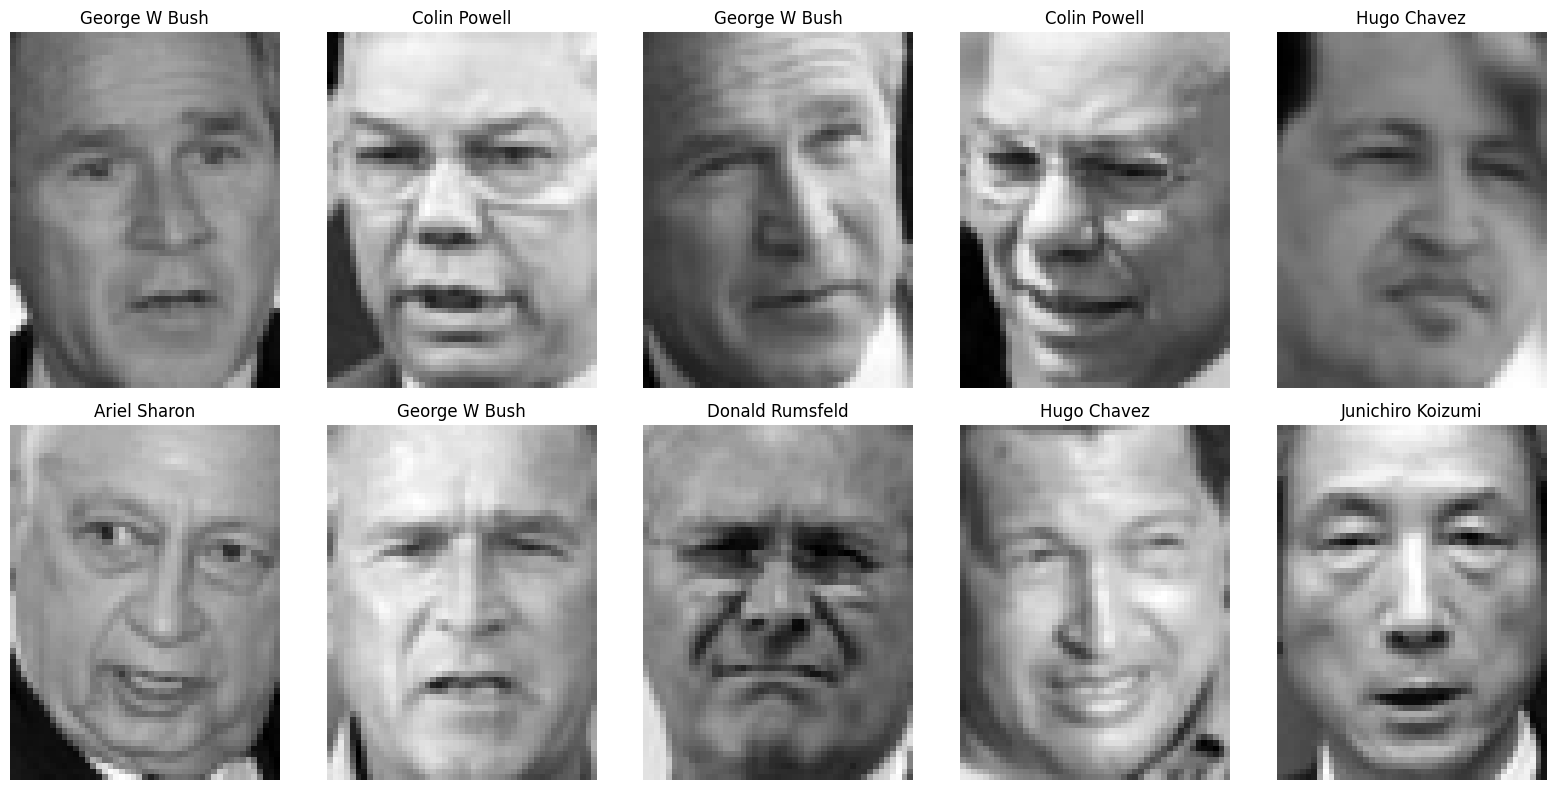

In [10]:
seed(9001)
indexs = list(range(len(dataset['images'])))
shuffle(indexs)

plt.figure(figsize=(16, 8))
for i in range(10):
    
    k = indexs[i]
    plt.subplot(2, 5, i+1)
    img = dataset['images'][k]
    plt.imshow(img, cmap='gray')
    plt.title(dataset['target_names'][dataset['target'][k]])
    plt.axis('off')

plt.tight_layout()
plt.show()
    

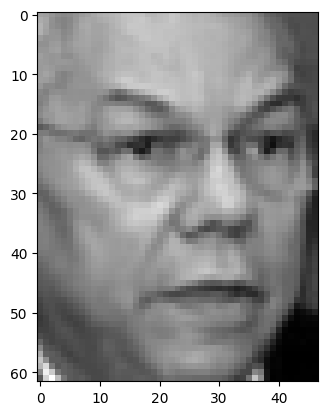

In [11]:
plt.imshow(dataset['images'][0], cmap='gray')

## Modelo PCA

In [ ]:
start = time()

## Instancia del modelo
pca_model = PCA(random_state=9001) #Aqui se crea un modelo PCA sin definir el numero de componentes

## Ajuste del modelo
pca_model.fit(dataset['data']) #Aqui se ajusta el modelo PCA a los datos
print('Number of Componets: {}'.format(pca_model.n_components_))

timeUp = time() #Aqui se mide el tiempo que demora el ajuste del modelo
print('Time spent[s]: {:.4f}'.format(timeUp - start))

##Aqui se crea un nuevo modelo PCA con el numero de componentes que se desea, el numero de componentes es arbitrario

Number of Componets: 1348
Time spent[s]: 1.2461


#### Visualización de algunos componentes principales

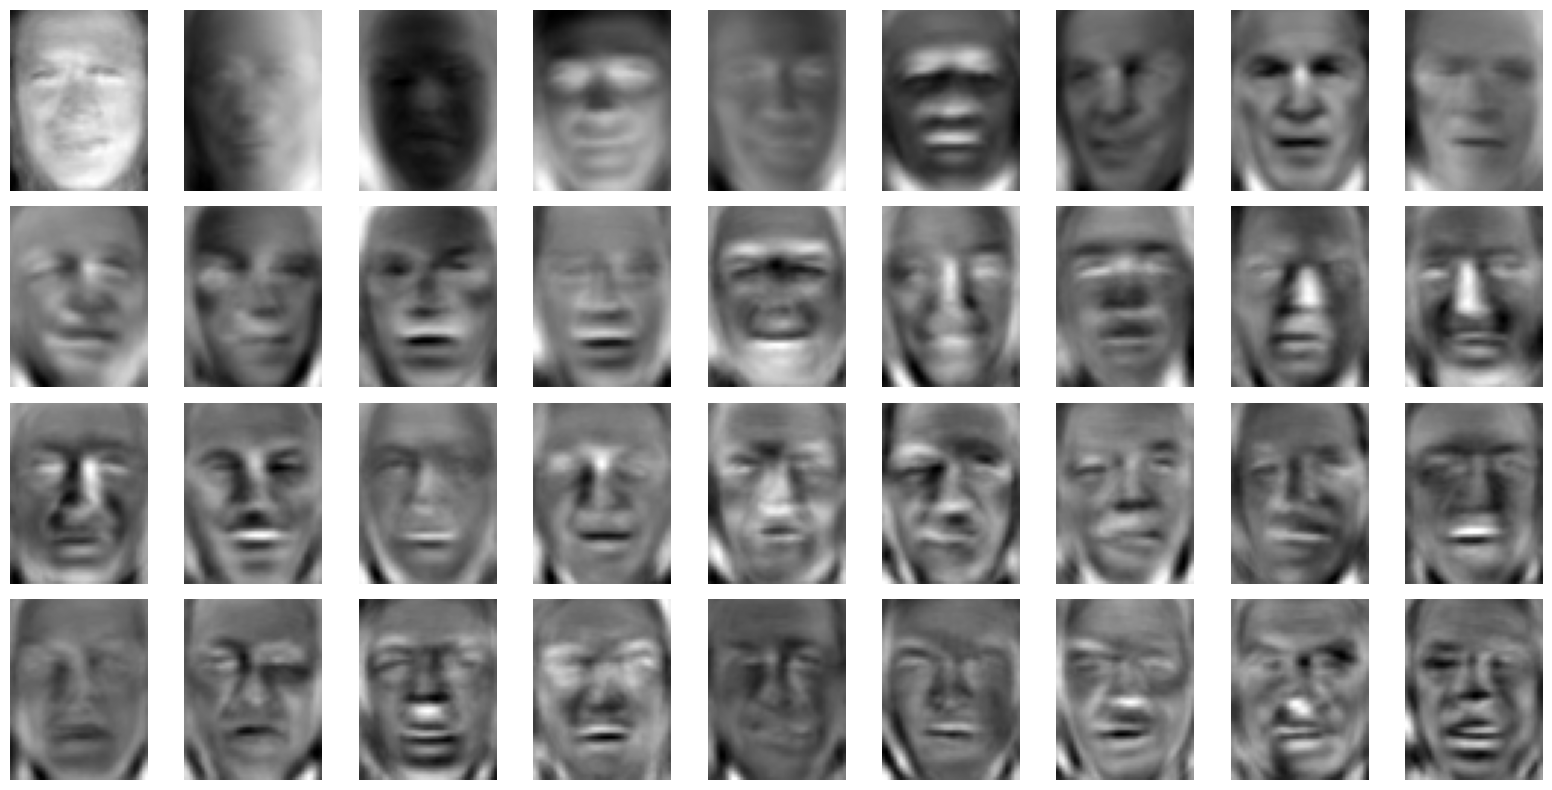

In [ ]:
plt.figure(figsize=(16, 8))
for i in range(36):
    
    plt.subplot(4, 9, i+1)
    pca_img = pca_model.components_[i].reshape(62, 47)
    plt.imshow(pca_img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Visualizacion de la transformacion de los datos originales a los datos reducidos, caras en funcion de los datos principales.

#### Visualización del porcentaje acumulativa de la varianza explicada

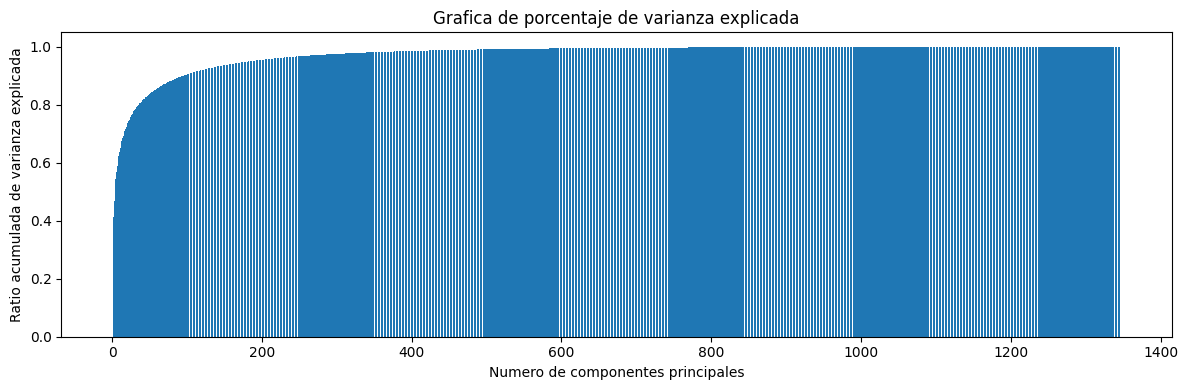

In [ ]:
## Numero de componentes
N = len(pca_model.explained_variance_ratio_) 

plt.figure(figsize=(12, 4))
plt.bar(x=range(N), 
        height=pca_model.explained_variance_ratio_.cumsum())
plt.xlabel('Numero de componentes principales')
plt.ylabel('Ratio acumulada de varianza explicada')
plt.title('Grafica de porcentaje de varianza explicada')
plt.tight_layout()
plt.show()

In [15]:
## Mostrar numericamente la varianza explicada. 
pca_model.explained_variance_ratio_.cumsum()

array([0.20795523, 0.34348193, 0.4113675 , ..., 1.0000002 , 1.0000006 ,
       1.0000006 ], shape=(1348,), dtype=float32)

In [16]:
## Encontrar la cantidad minima de componentes que contenga un cierta tasa de varianza explicada. 
(pca_model.explained_variance_ratio_.cumsum() <= 0.99).sum()

np.int64(471)

#### Transformación de las imagenes al espacio reducido

In [17]:
start = time()

## Instancia del modelo
pca_model = PCA(n_components=471, random_state=9001)

## Ajuste del modelo
pca_model.fit(dataset['data'])
print('Number of Componets: {}'.format(pca_model.n_components_))

timeUp = time()
print('Time spent[s]: {:.4f}'.format(timeUp - start))

Number of Componets: 471
Time spent[s]: 1.9259


In [18]:
X_pca = pca_model.transform(dataset['data'])
print('(shape) X by PCA: {}'.format(X_pca.shape))

(shape) X by PCA: (1348, 471)


#### Reconstrucción de las imagenes a partir del espacio reducido

In [19]:
X_reconstruido = pca_model.inverse_transform(X_pca)
print('(shape) X (reconstruida): {}'.format(X_reconstruido.shape))

(shape) X (reconstruida): (1348, 2914)


#### Visualización de las imagenes originales vs las reconstruidas

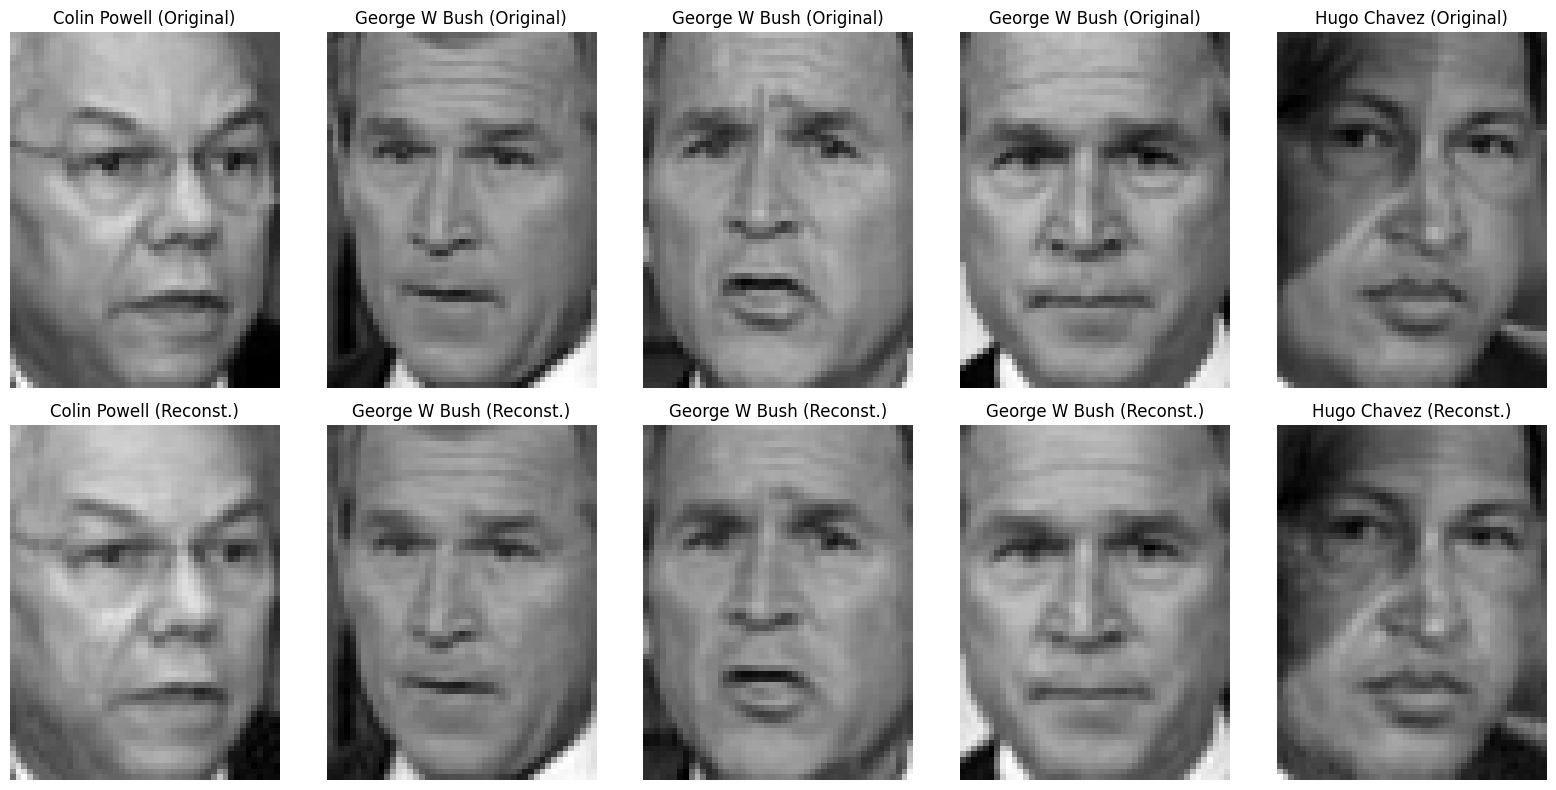

In [20]:
plt.figure(figsize=(16, 8))
for i in range(5):
    
    plt.subplot(2, 5, i+1)
    img_raw = dataset['images'][i]
    plt.imshow(img_raw, cmap='gray')
    plt.title('{} (Original)'.format(dataset['target_names'][dataset['target'][i]]))
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    img_rec = X_reconstruido[i].reshape(62, 47)
    plt.imshow(img_rec, cmap='gray')
    plt.title('{} (Reconst.)'.format(dataset['target_names'][dataset['target'][i]]))
    plt.axis('off')

plt.tight_layout()
plt.show()
    

In [21]:
pca_model.components_.shape

(471, 2914)